In [1]:
"""
GPP regional evaluation
@L. Leverne/F. Maignan/V. Tartaglione
"""

#import
import pandas as pd
import os
import sys
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors
import matplotlib.cm as cm
import numpy as np
import glob
import math
import xarray as xr
import netCDF4
import seaborn as sns
from mpl_toolkits.basemap import Basemap
from lmfit.models import LinearModel
from adjustText import adjust_text
from matplotlib.ticker import MaxNLocator

In [2]:
### fonctions
def rmse(observation, prediction):
    RMSE =math.sqrt(np.nanmean((np.array(observation)-np.array(prediction))**2))
    RMSE= round(RMSE,2)
    return RMSE

In [3]:
def rmse_weighted(observation, prediction,weights):
    RMSE = math.sqrt(np.nansum(((np.array(observation)-np.array(prediction))**2)*weights)/np.sum(weights))
    #RMSE = round(RMSE,2)
    return RMSE

In [4]:
def bias(prediction,observation):
    bias = (prediction - observation).mean()
    bias = round(bias,2)
    return bias

In [5]:
def amplitude(data):
    amp = np.max(data)-np.min(data)
    amp = round(amp,1)
    return amp

In [6]:
def my_corr(TAB1_arg,TAB2_arg):
    TAB1=np.ravel(TAB1_arg)
    TAB2=np.ravel(TAB2_arg)
    TAB1_valid=list(TAB1[np.logical_and(~np.isnan(TAB1),~np.isnan(TAB2))])
    TAB2_valid=list(TAB2[np.logical_and(~np.isnan(TAB1),~np.isnan(TAB2))])
    return np.corrcoef(TAB1_valid,TAB2_valid)[0,1]

In [7]:
def gpp_simu(path):
    data = xr.open_dataset(path)
    data.coords['mask'] = (mask_array)
    gpp=data['GPP']
    veget_cov_max=data['VEGET_COV_MAX' ]
    contfrac=data['CONTFRAC'].to_numpy()
    areas=data['Areas']
    #masking (->nan values)
    areas=areas.where(mask_array==2)
    areas=areas.to_numpy()
    gpp_total=np.sum(gpp*veget_cov_max,axis=1)*contfrac
    gpp_bacour = gpp_total.where(gpp_total.mask == 2)
    
    gpp_budget = (gpp_bacour*areas).sum(dim=['time_counter','lat','lon'])*365./12.* 1e-15
    gpp_budget=pd.DataFrame(data={'GPP':gpp_budget.values,'time_counter':years}, index=[0])
    gpp_budget=gpp_budget.set_index('time_counter')

    tstep = pd.date_range(start=years+'-01-01', periods=12, freq='M')
    gpp_bacour['time_counter'] = tstep
    bacour_final = gpp_bacour.drop(['time_centered','mask'])
    bacour_final =bacour_final.rename('GPP')

    return bacour_final, gpp_budget 

In [8]:
def budget_simu(path):
    data = xr.open_dataset(path)
    data.coords['mask'] = (mask_array)
    gpp=data['GPP']
    veget_cov_max=data['VEGET_COV_MAX' ]
    contfrac=data['CONTFRAC'].to_numpy()
    areas=data['Areas']
    #masking (->nan values)
    areas=areas.where(mask_array==2)
    areas=areas.to_numpy()

    gpp_total=np.sum(gpp*veget_cov_max,axis=1)*contfrac#*areas/np.nanmean(areas)
    gpp_bacour = gpp_total.where(gpp_total.mask == 2)
    gpp_budget = (gpp_bacour*areas).sum(dim=['time_counter','lat','lon'])*365./12.* 1e-15
    gpp_budget=pd.DataFrame(data={'GPP':gpp_budget.values,'time_counter':years}, index=[0])

    return gpp_budget

In [9]:
def filter_sites(data):
    return data[~data['remarques'].str.contains('eviter|éviter', case=False, na=False)]

In [10]:
# Function to calculate years for a site with prioritization
def calculate_prioritized_years(row):
    priority_order = ['warmwinter2020', 'fluxnet2015', 'fluxnet2007']
    for dataset in priority_order:
        start_col = f'year_{dataset}'
        if pd.notna(row[start_col]):
            start_year, end_year = map(int, row[start_col].split('-'))
            return end_year + 1 - start_year
    return 0

In [11]:
def calculate_years(year_ranges):
    total_years = 0
    for year_range in year_ranges.split('+'):
        start, end = map(int, year_range.split('-'))
        total_years += end + 1 - start
    return total_years

In [12]:
def get_site_category(site_id):
    if site_id in assimilation_sites:
        return 'Assimilation', colors[0]  # First color from colorblind palette
    elif site_id in evaluation_sites:
        return 'Evaluation', colors[3]  # Second color from colorblind palette
    else:
        return None, None

In [13]:
# IBM ColorBlind Safe palette
ibm_colors = [
        '#648FFF', '#785EF0', '#DC267F', '#FE6100', '#FFB000',
        '#009E73', '#56B4E9', '#E69F00', '#CC79A7', '#005AB5',
        '#F0E442', '#E6AB02', '#00A087', '#882255', '#AA4499'
    ]

### initialisations
list_obs2 =sorted(glob.glob('/home/surface6/cbacour/DATA/FLUXCOM-V2/GPP.monthly.2018.2021-0.5.nc'))

list_obs =sorted(glob.glob('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Vincent_2_2/INPUTS/GPP_FluxSat_monthly_v2.0_????-0.5.nc'))

list_bacour =sorted(glob.glob('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Vincent_NPQ/ARCHIVE/IGCM_OUT/OL2/DEVT/secsto/REGIONAL.PFT7.PRIOR.GDD/SBG/Output/MO/REGIONAL.PFT7.PRIOR.GDD_20*stomate_history.nc'))
list_optsif =sorted(glob.glob('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Vincent_NPQ/ARCHIVE/IGCM_OUT/OL2/DEVT/secsto/REGIONAL.PFT7.SIFONLY.GDD/SBG/Output/MO/REGIONAL.PFT7.SIFONLY.GDD_20*stomate_history.nc'))
list_raczka =sorted(glob.glob('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Vincent_NPQ/ARCHIVE/IGCM_OUT/OL2/DEVT/secsto/REGIONAL.PFT7.SIFGPP.GDD/SBG/Output/MO/REGIONAL.PFT7.SIFGPP.GDD_20*stomate_history.nc'))
list_optgpp =sorted(glob.glob('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Vincent_NPQ/ARCHIVE/IGCM_OUT/OL2/DEVT/secsto/REGIONAL.PFT7.GPPONLY.GDD/SBG/Output/MO/REGIONAL.PFT7.GPPONLY.GDD_20*stomate_history.nc'))
list_bacouropt =sorted(glob.glob('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Vincent_NPQ/ARCHIVE/IGCM_OUT/OL2/DEVT/secsto/REGIONAL.PFT7.SIFGPP.BACOUR.GDD/SBG/Output/MO/REGIONAL.PFT7.SIFGPP.BACOUR.GDD_20*stomate_history.nc'))

list_bacour = list_bacour[1:] 
list_optsif = list_optsif[1:]
list_raczka = list_raczka[1:]
list_optgpp = list_optgpp[1:] 
list_bacouropt = list_bacouropt[1:] 

dt_GPP_tot =pd.DataFrame()

obs_nY = []
obs2_nY = []
bacour_nY = []
raczka_nY = []
optgpp_nY = []
optsif_nY = []
bacouropt_nY = []
tot_bacour = []
tot_raczka = []
tot_optgpp = []
tot_optsif = []
tot_bacouropt = []
tot_weight = []
tot_tair = []
tot_veget = []

tot_budget_bacour = pd.DataFrame()
tot_budget_raczka = pd.DataFrame()
tot_budget_optgpp = pd.DataFrame()
tot_budget_optsif = pd.DataFrame()
tot_budget_bacouropt = pd.DataFrame()
tot_budget_FLUXSAT = pd.DataFrame()
tot_budget_FLUXCOM = pd.DataFrame()

seuil=0.5

In [14]:
#Read data 
obs = xr.open_dataset('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Lucas/MAP_data_EVALUATION_'+str(seuil)+'/gpp_obs_fluxsat_201222.nc')
obs2 = xr.open_dataset('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Lucas/MAP_data_EVALUATION_'+str(seuil)+'/gpp_obs_fluxcom_201222.nc')
bacour = xr.open_dataset('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Lucas/MAP_data_EVALUATION_'+str(seuil)+'/gpp_bacour_201222.nc')
raczka = xr.open_dataset('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Lucas/MAP_data_EVALUATION_'+str(seuil)+'/gpp_raczka_201222.nc')
optgpp = xr.open_dataset('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Lucas/MAP_data_EVALUATION_'+str(seuil)+'/gpp_optgpp_200122.nc')
optsif = xr.open_dataset('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Lucas/MAP_data_EVALUATION_'+str(seuil)+'/gpp_optsif_200122.nc')
bacouropt = xr.open_dataset('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Lucas/MAP_data_EVALUATION_'+str(seuil)+'/gpp_bacouropt_201222.nc')

obs = obs.rename({'time':'time_counter'})
obs2 = obs2.rename({'time':'time_counter'})

date_fin="2020-12-31"
obs = obs.sel(time_counter=slice("2001-01-01", date_fin))
obs2 = obs2.sel(time_counter=slice("2001-01-01", date_fin))
bacour = bacour.sel(time_counter=slice("2001-01-01", date_fin))
raczka = raczka.sel(time_counter=slice("2001-01-01", date_fin))
optsif = optsif.sel(time_counter=slice("2001-01-01", date_fin))
optgpp = optgpp.sel(time_counter=slice("2001-01-01", date_fin))
bacouropt = bacouropt.sel(time_counter=slice("2001-01-01", date_fin))

obs_sav = obs.copy()
obs2_sav = obs2.copy()
bacour_sav = bacour.copy()
raczka_sav = raczka.copy()
optsif_sav = optsif.copy()
optgpp_sav = optgpp.copy()
bacouropt_sav = bacouropt.copy()

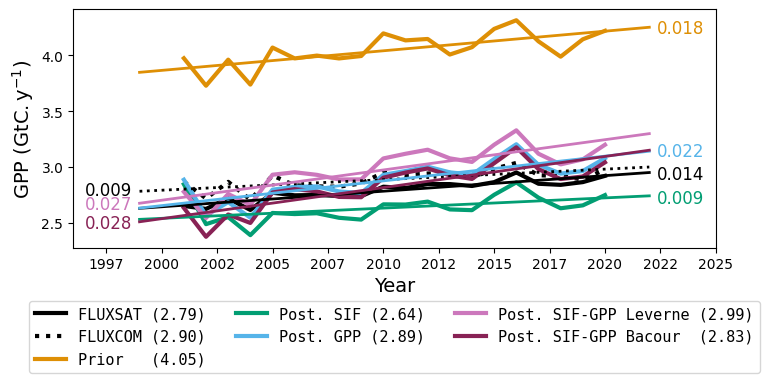

In [15]:
### Budgets
if True:
#Read data 
    df = pd.read_csv('budget_years.csv')

    fig, ax = plt.subplots(figsize=(8,4))

    list_type_obs = ['fluxsat','fluxcom','budget_bacour','budget_optsif','budget_optgpp','budget_opt','budget_bacouropt']
    color=['#000000', '#000000',
        sns.color_palette("colorblind")[1],    # orange
        sns.color_palette("colorblind")[2], # Green
        sns.color_palette("colorblind")[-1], # blue
        sns.color_palette("colorblind")[4],  # Pink
        ibm_colors[13]]           # burgundy

    #Plotting 
    fontsize_title=16
    fontsize_label=14
    fontsize_legend=11

    taille_trait = 3
   
    width=3
    label_format = "{:<{width}} ({:.2f})"
    plt.plot(df['years'], df['fluxsat'], linestyle ='solid', color='#000000',label=label_format.format('FLUXSAT',df['fluxsat'].mean(),width=width),linewidth=taille_trait)
    plt.plot(df['years'], df['fluxcom'], linestyle ='dotted', color='#000000',label=label_format.format('FLUXCOM',df['fluxcom'].mean(),width=width),linewidth=taille_trait)
    plt.plot(df['years'], df['budget_bacour'], color=sns.color_palette("colorblind")[1],label=label_format.format('Prior  ',df['budget_bacour'].mean(),width=width),linewidth=taille_trait)
    plt.plot(df['years'], df['budget_optsif'], color=sns.color_palette("colorblind")[2],label=label_format.format('Post. SIF',df['budget_optsif'].mean(),width=width),linewidth=taille_trait)
    plt.plot(df['years'], df['budget_optgpp'], color=sns.color_palette("colorblind")[-1],label=label_format.format('Post. GPP',df['budget_optgpp'].mean(),width=width),linewidth=taille_trait)
    plt.plot(df['years'], df['budget_opt'], color=sns.color_palette("colorblind")[4],label=label_format.format('Post. SIF-GPP Leverne',df['budget_opt'].mean(),width=width),linewidth=taille_trait)
    plt.plot(df['years'], df['budget_bacouropt'], color=ibm_colors[13],label=label_format.format('Post. SIF-GPP Bacour ',df['budget_bacouropt'].mean(),width=width),linewidth=taille_trait)

    type_obs_list = []
    a_list = []
    a_stderr_list = []
    X=range(1999,2023)
    for i,type_obs in enumerate(list_type_obs):
        model = LinearModel()
        params = model.guess(df[type_obs], x=df['years'])
        result = model.fit(df[type_obs], params, x=df['years'])
        if i==1:
            linestyle ='dotted'
        else:
            linestyle ='solid'
        plt.plot(X,result.params['slope'] * X + result.params['intercept'], linestyle = linestyle, color=color[i], linewidth=2)
        text_x = 2023.4  # Adjust the position of the text
        if i==0 or i==2 or i==3 or i==4:
            text_y = result.params['slope'] * text_x + result.params['intercept'] - 0.08 # Adjust the vertical position of the text
        else:
            text_x = 1997.6  # Adjust the position of the text
            text_y = result.params['slope'] * text_x + result.params['intercept'] - 0.02 # Adjust the vertical position of the text
        a = round(result.params['slope'].value,3)
        plt.text(text_x, text_y, f'{a}', fontsize=12, ha='center', color=color[i])        
        a_stderr = round(result.params['slope'].stderr,3)
        
        type_obs_list.append(type_obs)
        a_list.append(a)
        a_stderr_list.append(a_stderr)
    ax.set_xlim(left=1996,right=2025)
    ax.xaxis.set_major_locator(plt.MultipleLocator(2))
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x)}"))
    
    tbl_slope = {
        'type_obs': type_obs_list,
        'a': a_list,
        'a_stderr': a_stderr_list}

    tbl_slope = pd.DataFrame(tbl_slope)
    
    ax.set_ylabel("GPP ($\mathrm{GtC.y^{-1}}$)",fontsize=fontsize_label)
    ax.set_xlabel('Year',fontsize=fontsize_label)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=12))
    plt.subplots_adjust(bottom=0.2)

    plt.legend(loc='upper center', prop={'family': 'DejaVu Sans Mono', 'size': fontsize_legend}, bbox_to_anchor=(0.5, -0.19), ncol=3)
    plt.rcParams['font.family'] = 'monospace'
    plt.tight_layout()
    plt.show(block = False)
    #plt.savefig("./PNG/Figure7.png",format='png',dpi=300)

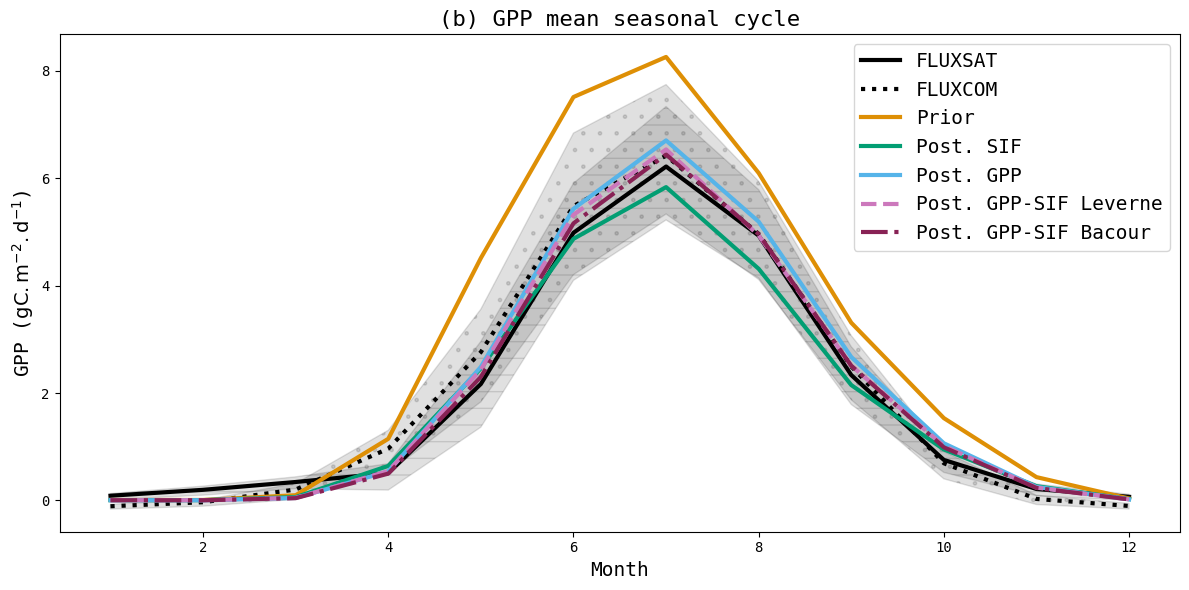

In [16]:
### Mean seasonal cycles
if True:
    obs = obs_sav.copy()
    obs2 = obs2_sav.copy()
    bacour = bacour_sav.copy()
    raczka = raczka_sav.copy()
    optsif = optsif_sav.copy()
    optgpp = optgpp_sav.copy()
    bacouropt = bacouropt_sav.copy()

    obs = obs.groupby('time_counter.month').mean(dim=['time_counter','lat','lon'])
    obs_std = obs_sav.groupby('time_counter.month').std(dim=['time_counter','lat','lon'])
    obs_q1 = obs_sav.groupby('time_counter.month').quantile(0.25,dim=['time_counter','lat','lon'])
    obs_q3 = obs_sav.groupby('time_counter.month').quantile(0.75,dim=['time_counter','lat','lon'])
    obs = pd.DataFrame(data={'time':obs.month,'GPP': obs.GPP,'std': obs_std.GPP,'q1': obs_q1.GPP,'q3': obs_q3.GPP})

    obs2_sav = obs2.copy()
    obs2 = obs2.groupby('time_counter.month').mean(dim=['time_counter','lat','lon'])
    obs2_std = obs2_sav.groupby('time_counter.month').std(dim=['time_counter','lat','lon'])
    obs2_q1 = obs2_sav.groupby('time_counter.month').quantile(0.25,dim=['time_counter','lat','lon'])
    obs2_q3 = obs2_sav.groupby('time_counter.month').quantile(0.75,dim=['time_counter','lat','lon'])
    obs2 = pd.DataFrame(data={'time':obs2.month,'GPP': obs2.GPP,'std': obs2_std.GPP,'q1': obs2_q1.GPP,'q3': obs2_q3.GPP})

    bacour = bacour.groupby('time_counter.month').mean(dim=['time_counter','lat','lon'])
    bacour = pd.DataFrame(data={'time':bacour.month,'GPP': bacour.GPP})
    raczka = raczka.groupby('time_counter.month').mean(dim=['time_counter','lat','lon'])
    raczka = pd.DataFrame(data={'time':raczka.month,'GPP': raczka.GPP})
    optsif = optsif.groupby('time_counter.month').mean(dim=['time_counter','lat','lon'])
    optsif = pd.DataFrame(data={'time':optsif.month,'GPP': optsif.GPP})
    optgpp = optgpp.groupby('time_counter.month').mean(dim=['time_counter','lat','lon'])
    optgpp = pd.DataFrame(data={'time':optgpp.month,'GPP': optgpp.GPP})
    bacouropt = bacouropt.groupby('time_counter.month').mean(dim=['time_counter','lat','lon'])
    bacouropt = pd.DataFrame(data={'time':bacouropt.month,'GPP': bacouropt.GPP})

    fontsize_title=16
    fontsize_label=14
    fontsize_legend=14

    taille_trait = 3

    fig, ax = plt.subplots(figsize=(12,6))
    plt.plot(obs['time'], obs['GPP'], color='#000000',         label='FLUXSAT',linewidth=taille_trait)
    plt.fill_between(obs['time'], obs['q1'], obs['q3'],
        alpha=0.12, hatch="-", edgecolor='#000000', facecolor='#000000')

    plt.plot(obs2['time'], obs2['GPP'], color='#000000',    label='FLUXCOM',linewidth=taille_trait,linestyle='dotted')
    plt.fill_between(obs2['time'], obs2['q1'], obs2['q3'],
        alpha=0.12, hatch= ".", edgecolor='#000000', facecolor='#000000')
        
    plt.plot(bacour['time'], bacour['GPP'], color=sns.color_palette("colorblind")[1],label='Prior',linewidth=taille_trait)
    plt.plot(optsif['time'], optsif['GPP'], color=sns.color_palette("colorblind")[2],label='Post. SIF',linewidth=taille_trait)
    plt.plot(optgpp['time'], optgpp['GPP'], color=sns.color_palette("colorblind")[-1],label='Post. GPP',linewidth=taille_trait)
    plt.plot(raczka['time'], raczka['GPP'], color=sns.color_palette("colorblind")[4],label='Post. GPP-SIF Leverne',linewidth=taille_trait,linestyle='dashed')
    plt.plot(bacouropt['time'], bacouropt['GPP'], color=ibm_colors[13],label='Post. GPP-SIF Bacour',linewidth=taille_trait,linestyle='-.')

    ax.set_title('(b) GPP mean seasonal cycle',fontsize=fontsize_title)
    ax.set_ylabel("GPP ($\mathrm{gC.m^{-2}.d^{-1}}$)",fontsize=fontsize_label)
    ax.set_xlabel('Month',fontsize=fontsize_label)
    plt.subplots_adjust(bottom=0.35)

    plt.legend(fontsize=fontsize_legend)
    plt.tight_layout()
    plt.show(block = False)
    #plt.savefig('PNG/Figure6b.png', format='png',dpi=300, bbox_inches='tight')

/home/users/maignan/.local/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


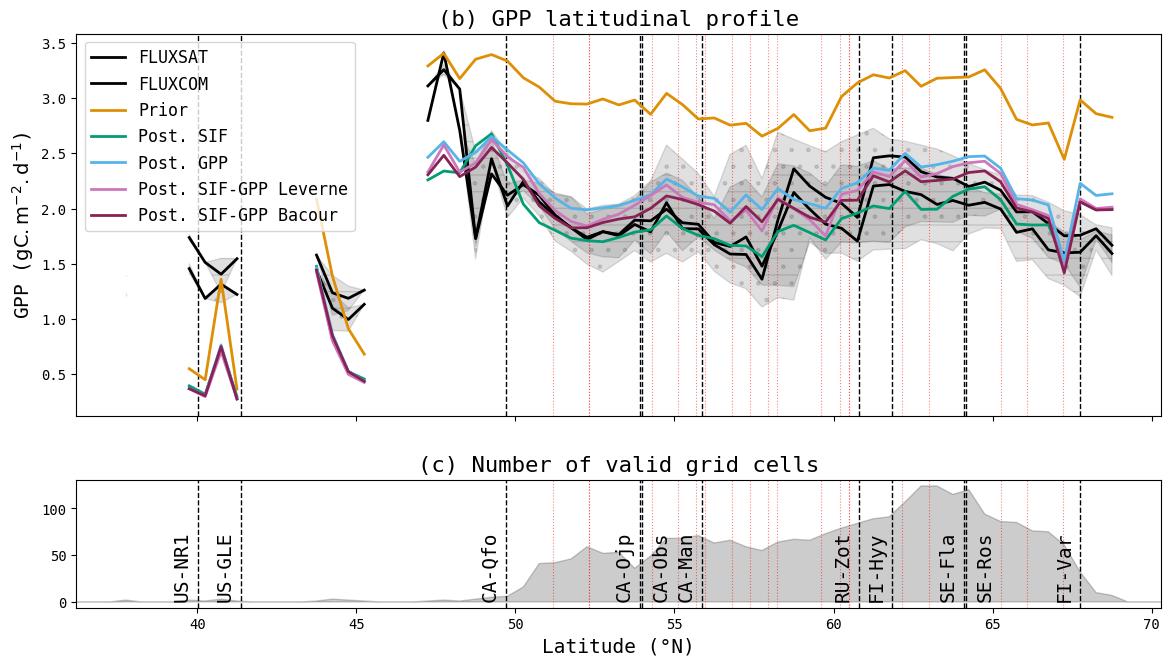

In [17]:
### Latitudinal profiles
if True:
    obs = obs_sav.copy()
    obs2 = obs2_sav.copy()
    bacour = bacour_sav.copy()
    raczka = raczka_sav.copy()
    optsif = optsif_sav.copy()
    optgpp = optgpp_sav.copy()
    bacouropt = bacouropt_sav.copy()

    #Processing sites
    #Read CSV files
    sites = pd.read_csv('./lat_lon_site.csv')
    df = pd.read_csv('./site_list_new.csv')

    # Apply year calculation
    df['prioritized_years'] = df.apply(calculate_prioritized_years, axis=1)

    unique_pfts = df['dominant_orchidee_pft'].unique()
    
    # Define lists for assimilation and evaluation sites 
    assimilation_sites = {'CA-Man': '1998-2003', 
                    'CA-Qfo': '2004-2010',
                    'FI-Hyy': '1996-2019', 
                    'FI-Var': '2016-2020', 
                    'RU-Zot': '2002-2004', 
                    'SE-Fla': '1996-1998+2001-2003', 
                    'SE-Ros': '2015-2020',
                    'CA-Obs': '2000-2005', 
                    'CA-Ojp': '2000-2005', 
                    'US-GLE': '2005-2014', 
                    'US-NR1':'1999-2014'}
    
    evaluation_sites = { 
                    'CA-NS5': '2002-2005',
                    'CA-NS6': '2002-2005',
                    'FI-Ken': '2018-2019', 
                    'FI-Sod': '2001-2014',
                    'SE-Svb': '2014-2016+2018-2020',
                    'US-Syv': '2001-2006+2012-2014'}
                     
    pft_data = df[df['dominant_orchidee_pft'] == 'PFT07']
    # Filter out sites to avoid
    pft_data = filter_sites(pft_data)

    # Filter data for assimilation and evaluation sites only
    relevant_sites = list(assimilation_sites.keys()) + list(evaluation_sites.keys())
    relevant_sites_assimilation = list(assimilation_sites.keys())
    relevant_sites_evaluation   = list(evaluation_sites.keys())
    filtered_data = pft_data[pft_data['id'].isin(relevant_sites)]
    filtered_data_assimilation = pft_data[pft_data['id'].isin(relevant_sites_assimilation)]
    filtered_data_evaluation   = pft_data[pft_data['id'].isin(relevant_sites_evaluation)]

    #grid cells
    assim_pixels = pd.read_csv(f'/home/users/vtartagl/Assim_SIF-GPP/assim-eval_distribution/GC/assimilation_pixels_pft07_ampl_3.csv', sep=',')

    if True:
        mask_negative = obs2['GPP'] < 0
        obs2['GPP'] = obs2['GPP'].where(~mask_negative, 0)

    #We first compute annual means.
    obs = obs.GPP.mean(['time_counter'])
    obs2 = obs2.GPP.mean(['time_counter'])
    bacour = bacour.GPP.mean(['time_counter'])
    raczka = raczka.GPP.mean(['time_counter'])
    optsif = optsif.GPP.mean(['time_counter'])
    optgpp = optgpp.GPP.mean(['time_counter'])
    bacouropt = bacouropt.GPP.mean(['time_counter'])
    
    #We compute standard deviation on longitude.
    obs_std = obs.std(['lon'])
    obs2_std = obs2.std(['lon'])
    optgpp_std = optgpp.std(['lon'])

    obs_q1 = obs.quantile(0.25,dim=['lon'])
    obs_q3 = obs.quantile(0.75,dim=['lon'])
    obs2_q1 = obs2.quantile(0.25,dim=['lon'])
    obs2_q3 = obs2.quantile(0.75,dim=['lon'])

    # Count the number of non-null values for each lat
    non_null_count = obs.count(dim='lon')

    do_median=True
    if do_median:
        obs = obs.median(['lon'])
        obs2 = obs2.median(['lon'])
        bacour = bacour.median(['lon'])
        raczka = raczka.median(['lon'])
        optsif = optsif.median(['lon'])
        optgpp = optgpp.median(['lon'])
        bacouropt = bacouropt.median(['lon'])
    else:
        obs = obs.mean(['lon'])
        obs2 = obs2.mean(['lon'])
        bacour = bacour.mean(['lon'])
        raczka = raczka.mean(['lon'])
        optsif = optsif.mean(['lon'])
        optgpp = optgpp.mean(['lon'])
        bacouropt = bacouropt.mean(['lon'])

    fontsize_title=16
    fontsize_label=14
    fontsize_legend=12

    fig, (ax, ax2) = plt.subplots(2, 1, figsize=(14,7), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
    ax.fill_between(obs.lat.values,obs_q1.values, obs_q3.values,
        alpha=0.12, edgecolor='black', facecolor='black',hatch='-')
    ax.fill_between(obs2.lat.values,obs2_q1.values, obs2_q3.values,
        alpha=0.12, edgecolor='black', facecolor='black',hatch='.')

# Add vertical lines for grid cells
    for i in assim_pixels.index:
        ax.axvline(x=assim_pixels.latitude[i], color='red', linestyle=':', linewidth=0.8, alpha=0.5)  # Add the vertical line
    
    # Add vertical lines with labels
    for i in filtered_data_assimilation.index:
        ax.axvline(x=filtered_data_assimilation.lat[i], color='black', linestyle='--', linewidth=1)  # Add the vertical line

    ax.plot(obs.lat.values, obs.values, label="FLUXSAT", color='black', linewidth=2)
    ax.plot(obs2.lat.values, obs2.values, label="FLUXCOM", color='black', linewidth=2)
    ax.plot(bacour.lat.values, bacour.values, label="Prior",color=sns.color_palette("colorblind")[1], linewidth=2)
    ax.plot(optsif.lat.values, optsif.values, label="Post. SIF",color=sns.color_palette("colorblind")[2], linewidth=2)
    ax.plot(optgpp.lat.values, optgpp.values, label="Post. GPP",color=sns.color_palette("colorblind")[-1], linewidth=2)
    ax.plot(raczka.lat.values, raczka.values, label="Post. SIF-GPP Leverne",color=sns.color_palette("colorblind")[4], linewidth=2)
    ax.plot(bacouropt.lat.values, bacouropt.values, label="Post. SIF-GPP Bacour",color=ibm_colors[13], linewidth=2)

    ax.set_title('(b) GPP latitudinal profile',fontsize=fontsize_title)
    ax.set_ylabel('GPP ($\mathrm{gC.m^{-2}.d^{-1}}$)',fontsize=fontsize_label)
    ax.set_xlabel('',fontsize=fontsize_label)
    ax.legend(fontsize=fontsize_legend)

    # Manually set the x-axis limits for ax2
    ax2.set_xlim(ax.get_xlim())
    ax2.fill_between(non_null_count.lat.values, 0, non_null_count.values, alpha=0.2, edgecolor='black', facecolor='black')
    ax2.set_title('(c) Number of valid grid cells',fontsize=fontsize_title)
    ax2.set_xlabel('Latitude (°N)',fontsize=fontsize_label)

# Add vertical lines for grid cells
    for i in assim_pixels.index:
        ax2.axvline(x=assim_pixels.latitude[i], color='red', linestyle=':', linewidth=0.8, alpha=0.5)  # Add the vertical line

    for i in filtered_data_assimilation.index:
        ax2.axvline(x=filtered_data_assimilation.lat[i], color='black', linestyle='--', linewidth=1)  # Add the vertical line
        #if i==46 or i==199: #CA-Ojp/SE-Ros
        if (filtered_data_assimilation.id[i]=='CA-Obs') | (filtered_data_assimilation.id[i]=='SE-Ros'):
            ax2.text(filtered_data_assimilation.lat[i]+0.6, 5, filtered_data_assimilation.id[i], rotation='vertical', ha='center', fontsize=fontsize_label)  #
        else:
            ax2.text(filtered_data_assimilation.lat[i]-0.5, 5, filtered_data_assimilation.id[i], rotation='vertical', ha='center', fontsize=fontsize_label)  #

    fig.subplots_adjust(hspace=0.25,top=0.92,bottom=0.1)
    plt.show(block=False)
    #plt.savefig('PNG/gpp_latitudinal_profile_'+str(seuil)+'_V14_nocontfracobs.png', format='png',dpi=300, bbox_inches='tight')